# House Price Prediction - Multiple Models
This notebook trains multiple models and compares their performance.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

In [2]:
# Load data
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

### EDA for Train data

In [3]:
train.shape

(1460, 81)

In [4]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
train.info

<bound method DataFrame.info of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Ut

In [6]:
##For numerical variables
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
##For Categorical variables
train.describe(include='object')



,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


| Metric     | Meaning                       |
| ---------- | ----------------------------- |
| **count**  | Number of non-null values     |
| **unique** | Number of distinct categories |
| **top**    | Most frequent category        |
| **freq**   | Frequency of the top category |


In [8]:
#Check Missing Values in Descending order
train.isnull().sum().sort_values(ascending=False)

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [9]:
#Separate numerical and Caegorical features
num_cols = train.select_dtypes(exclude='object').columns
cat_cols = train.select_dtypes(include='object').columns

In [10]:
#Display numerical features
print(num_cols)

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


In [11]:
len(num_cols)

38

In [12]:
#Display Categorical features
print(cat_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [13]:
len(cat_cols)

43

<Axes: xlabel='SalePrice', ylabel='Count'>

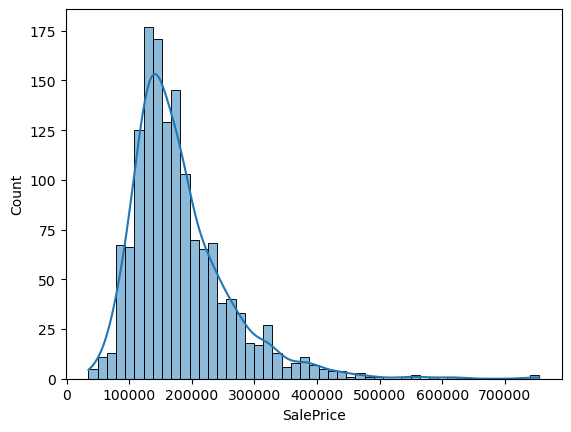

In [14]:
#Analyse the Target Variable-Saleprice or Check Skeweness
import seaborn as sns
sns.histplot(train['SalePrice'], kde=True)

# Observation
# 1.Most houses are at low price-Range between 100000 to 250000.
# 2.It is Right skewed distribution
# 3.We need to convert skewed data into Normal Distribution(Bell Shaped) to increase accuracy and decrease RMSE

In [15]:
#Checking skeweness numerically
train['SalePrice'].skew()

np.float64(1.8828757597682129)

# 1.8 Refers to Higly Right Skewed

In [16]:
#Applying log transformation
train['SalePrice'] = np.log1p(train['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

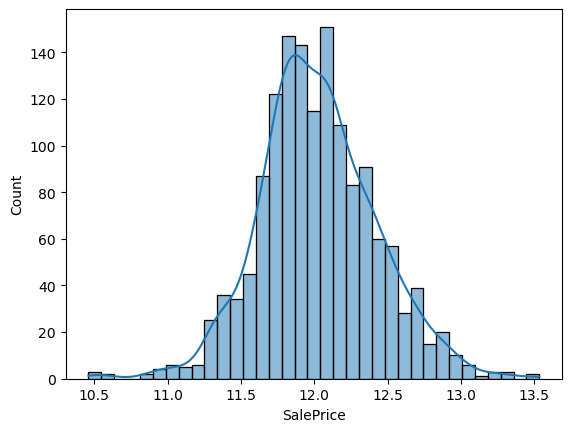

In [17]:
#Hist plot after applying log transformation
sns.histplot(train['SalePrice'], kde=True)

# Observations
# 1.After applying log transformation we can see more normal distribution

# After training remove log or converts values back to original scale
preds = np.expm1(model.predict(df_test))

# Univariate Analysis

array([[<Axes: title={'center': 'Id'}>,
        <Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>],
       [<Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>,
        <Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>],
       [<Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>,
        <Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>],
       [<Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,

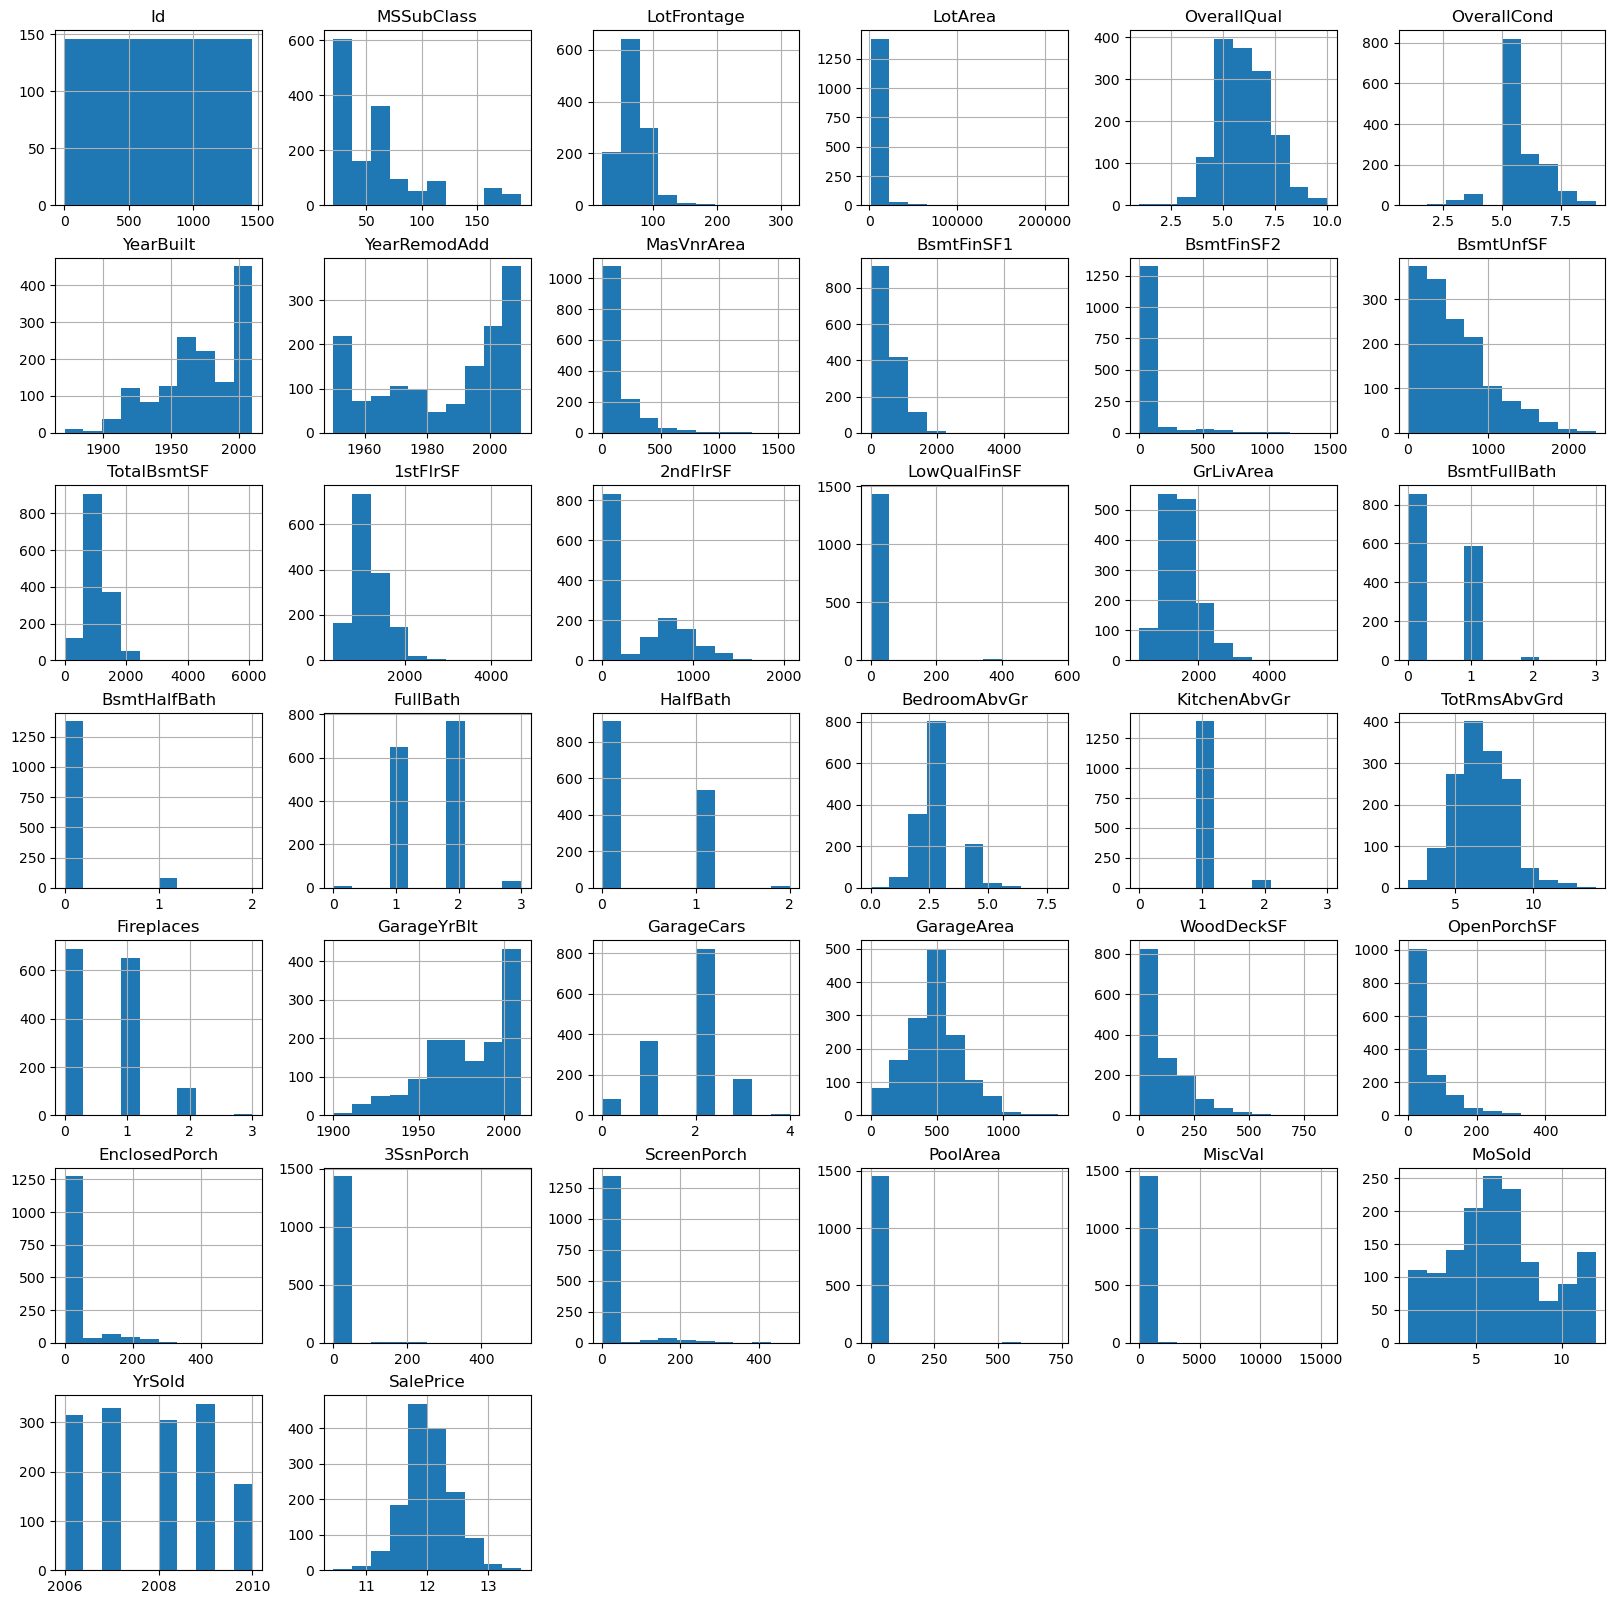

In [18]:
#Numerical feature Analysis
train[num_cols].hist(figsize=(20, 20))

In [19]:
#Categorical feature Analysis
for col in cat_cols:
    print(train[col].value_counts())

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
Alley
Grvl    50
Pave    41
Name: count, dtype: int64
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker   

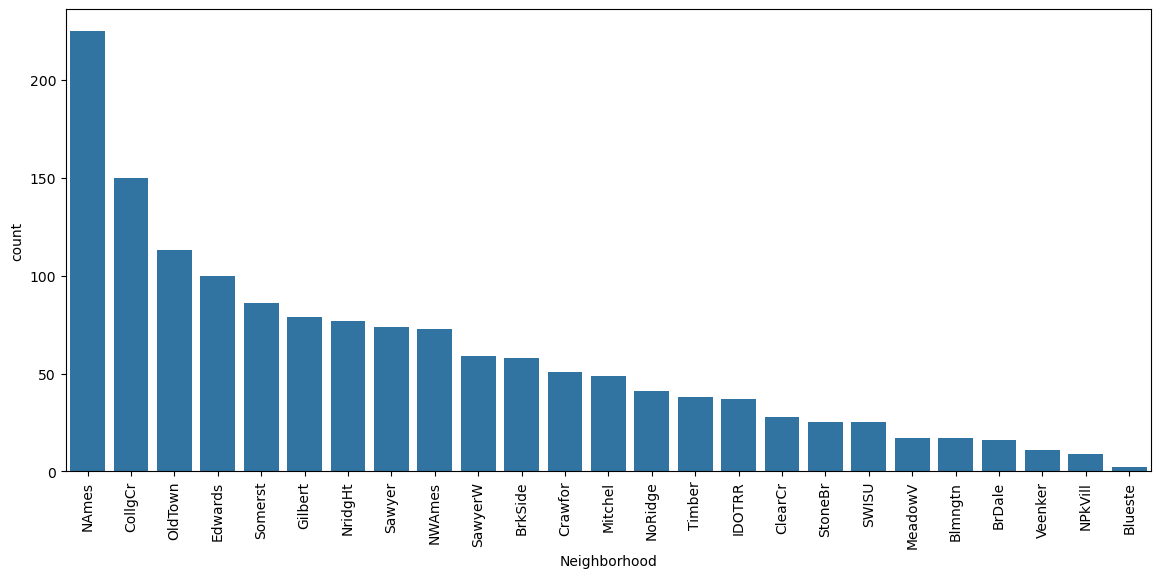

In [20]:
#Visualisation of Categorical features
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
sns.countplot(
    x='Neighborhood',
    data=train,
    order=train['Neighborhood'].value_counts().index
)
plt.xticks(rotation=90)
plt.show()

# Observations
# Dataset is imbalanced acroos neighborhood as we can see very few neighbourhoods has high count and many neighbourhoods has low count.
# Some neighborhoods are underrepresented (rare categories)


# Bivariate Analysis

<Axes: xlabel='GrLivArea', ylabel='SalePrice'>

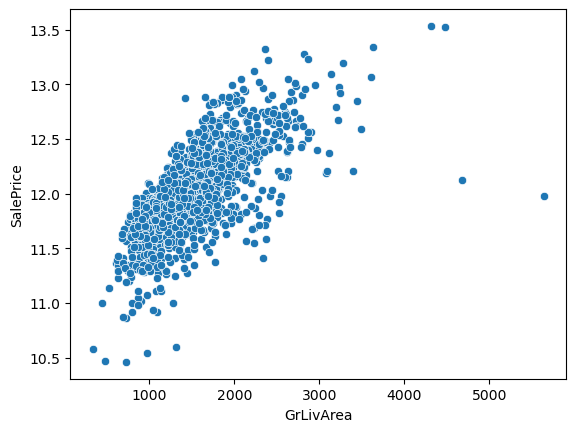

In [21]:
#Numerical features V/S Target feature
import seaborn as sns
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])

<Axes: xlabel='Neighborhood', ylabel='SalePrice'>

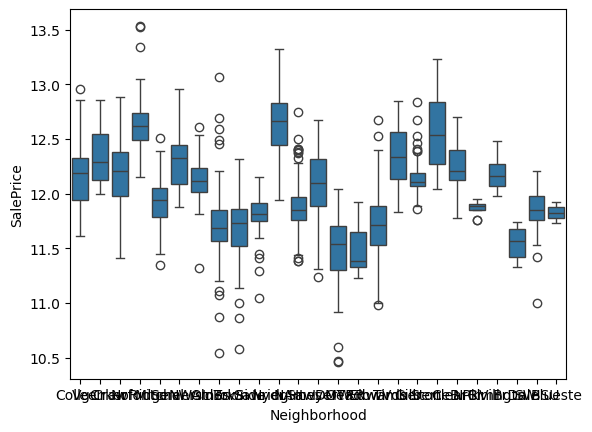

In [22]:
#Categorical V/S Target feature
#Option 1
sns.boxplot(x='Neighborhood', y='SalePrice', data=train)

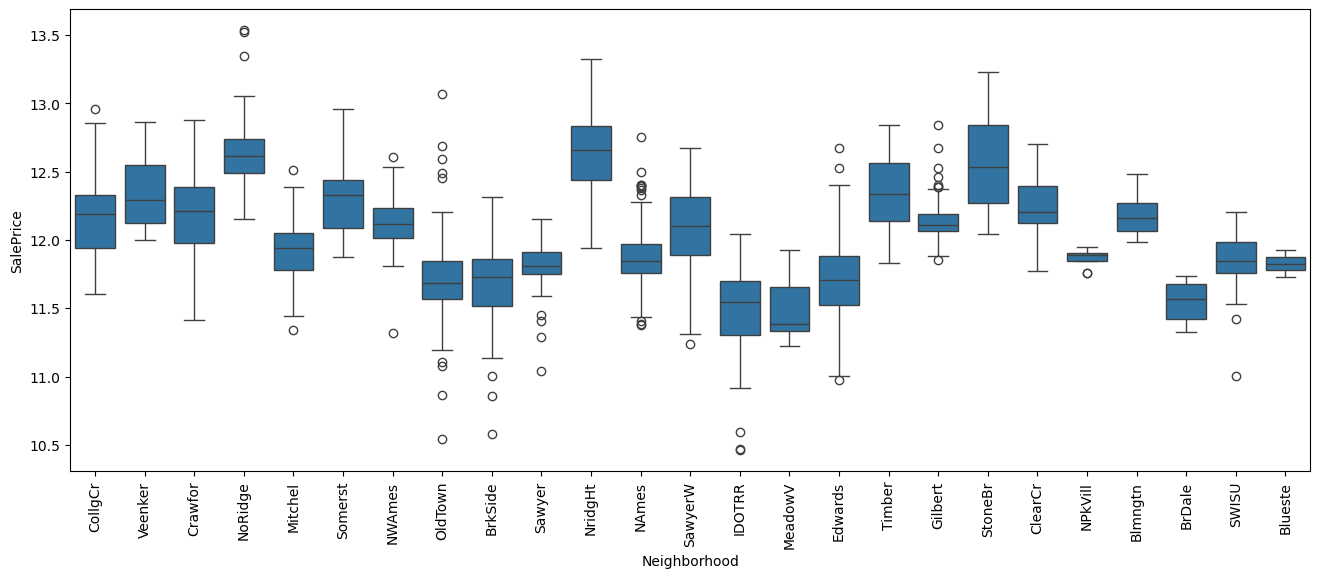

In [23]:
#As the many are overlapping use this code-Visualisation of Categorial v/s Target by increasing size and rotation
#Option 2
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=train)
plt.xticks(rotation=90)
plt.show()

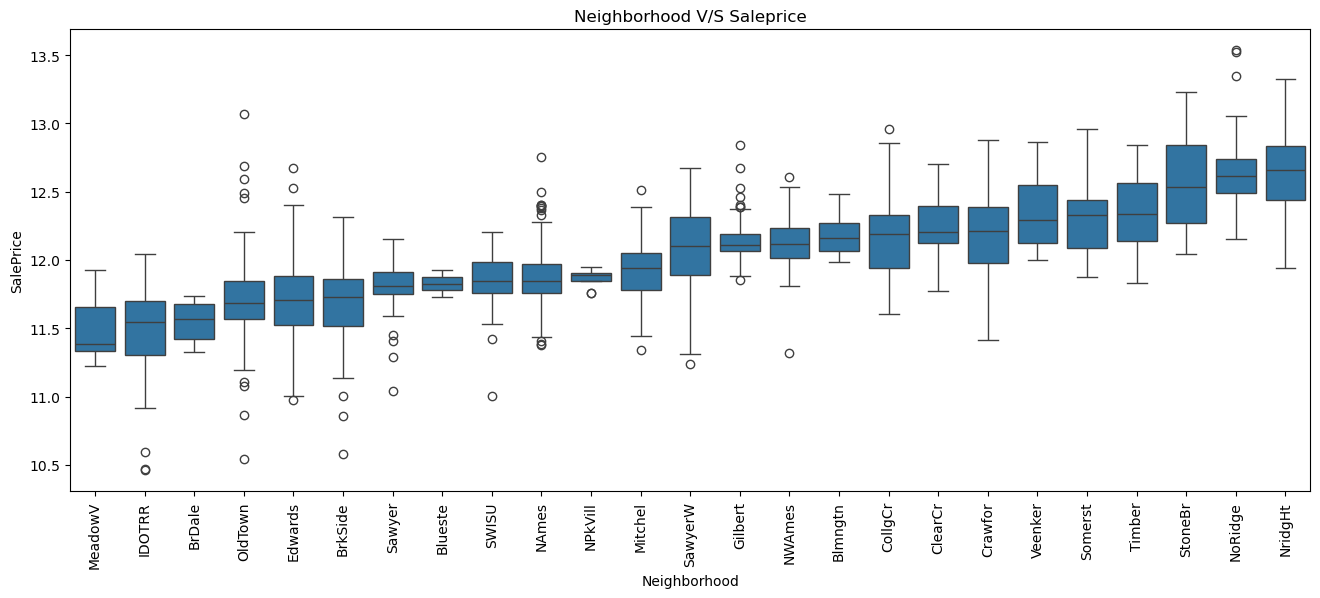

In [24]:
#Visualisation of Categorial v/s Target-Sorting by median price
#Option 3

plt.figure(figsize=(16,6))

order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index

sns.boxplot(x='Neighborhood', y='SalePrice', data=train, order=order)

plt.xticks(rotation=90)
plt.title('Neighborhood V/S Saleprice')
plt.show()

# Observation
# The left has cheap neighbourhoods has the cheap price and where as right has expensive neighborhood i.e the prices are costly
# High median value-Expensive Neighborhood and Low Median value-Cheap Neighborhood

In [25]:
#Correlation Analysis
corr = train[num_cols].corr()
#sns.heatmap(corr, cmap='coolwarm')
corr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.017942
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.073959
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.355879
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.257320
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.817185
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.036868
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.586570
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.565608
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.430809
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.372023


<Axes: >

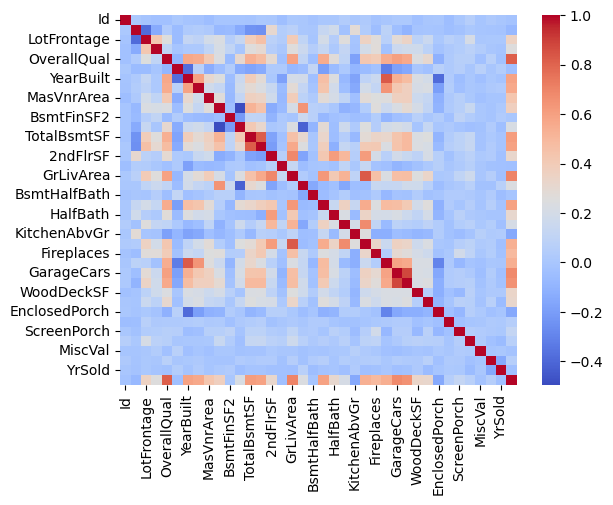

In [26]:
sns.heatmap(corr, cmap='coolwarm')

In [27]:
#Compute Correlation matrix
corr = train[num_cols].corr()
#Looking for Correlation with Target-SalePrice
corr_target = corr['SalePrice'].sort_values(ascending=False)
print(corr_target)

SalePrice        1.000000
OverallQual      0.817185
GrLivArea        0.700927
GarageCars       0.680625
GarageArea       0.650888
TotalBsmtSF      0.612134
1stFlrSF         0.596981
FullBath         0.594771
YearBuilt        0.586570
YearRemodAdd     0.565608
GarageYrBlt      0.541073
TotRmsAbvGrd     0.534422
Fireplaces       0.489450
MasVnrArea       0.430809
BsmtFinSF1       0.372023
LotFrontage      0.355879
WoodDeckSF       0.334135
OpenPorchSF      0.321053
2ndFlrSF         0.319300
HalfBath         0.313982
LotArea          0.257320
BsmtFullBath     0.236224
BsmtUnfSF        0.221985
BedroomAbvGr     0.209043
ScreenPorch      0.121208
PoolArea         0.069798
MoSold           0.057330
3SsnPorch        0.054900
BsmtFinSF2       0.004832
BsmtHalfBath    -0.005149
Id              -0.017942
MiscVal         -0.020021
OverallCond     -0.036868
YrSold          -0.037263
LowQualFinSF    -0.037963
MSSubClass      -0.073959
KitchenAbvGr    -0.147548
EnclosedPorch   -0.149050
Name: SalePr

In [28]:
# Finding Higly Correlated features among predictors
# Set a threshold
threshold = 0.8

# Find pairs of highly correlated features
high_corr = corr.abs() > threshold
high_corr_pairs = []

for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if high_corr.iloc[i,j]:
            pair = (corr.columns[i], corr.columns[j], corr.iloc[i,j])
            high_corr_pairs.append(pair)

# Display
high_corr_pairs

[('OverallQual', 'SalePrice', np.float64(0.8171846144867677)),
 ('YearBuilt', 'GarageYrBlt', np.float64(0.8256674841743408)),
 ('TotalBsmtSF', '1stFlrSF', np.float64(0.8195299750050339)),
 ('GrLivArea', 'TotRmsAbvGrd', np.float64(0.8254893743088425)),
 ('GarageCars', 'GarageArea', np.float64(0.882475414281462))]

# 'OverallQual', 'SalePrice' are highly Correlated

# Outlier Detection

ValueError: num must be an integer with 1 <= num <= 36, not 37

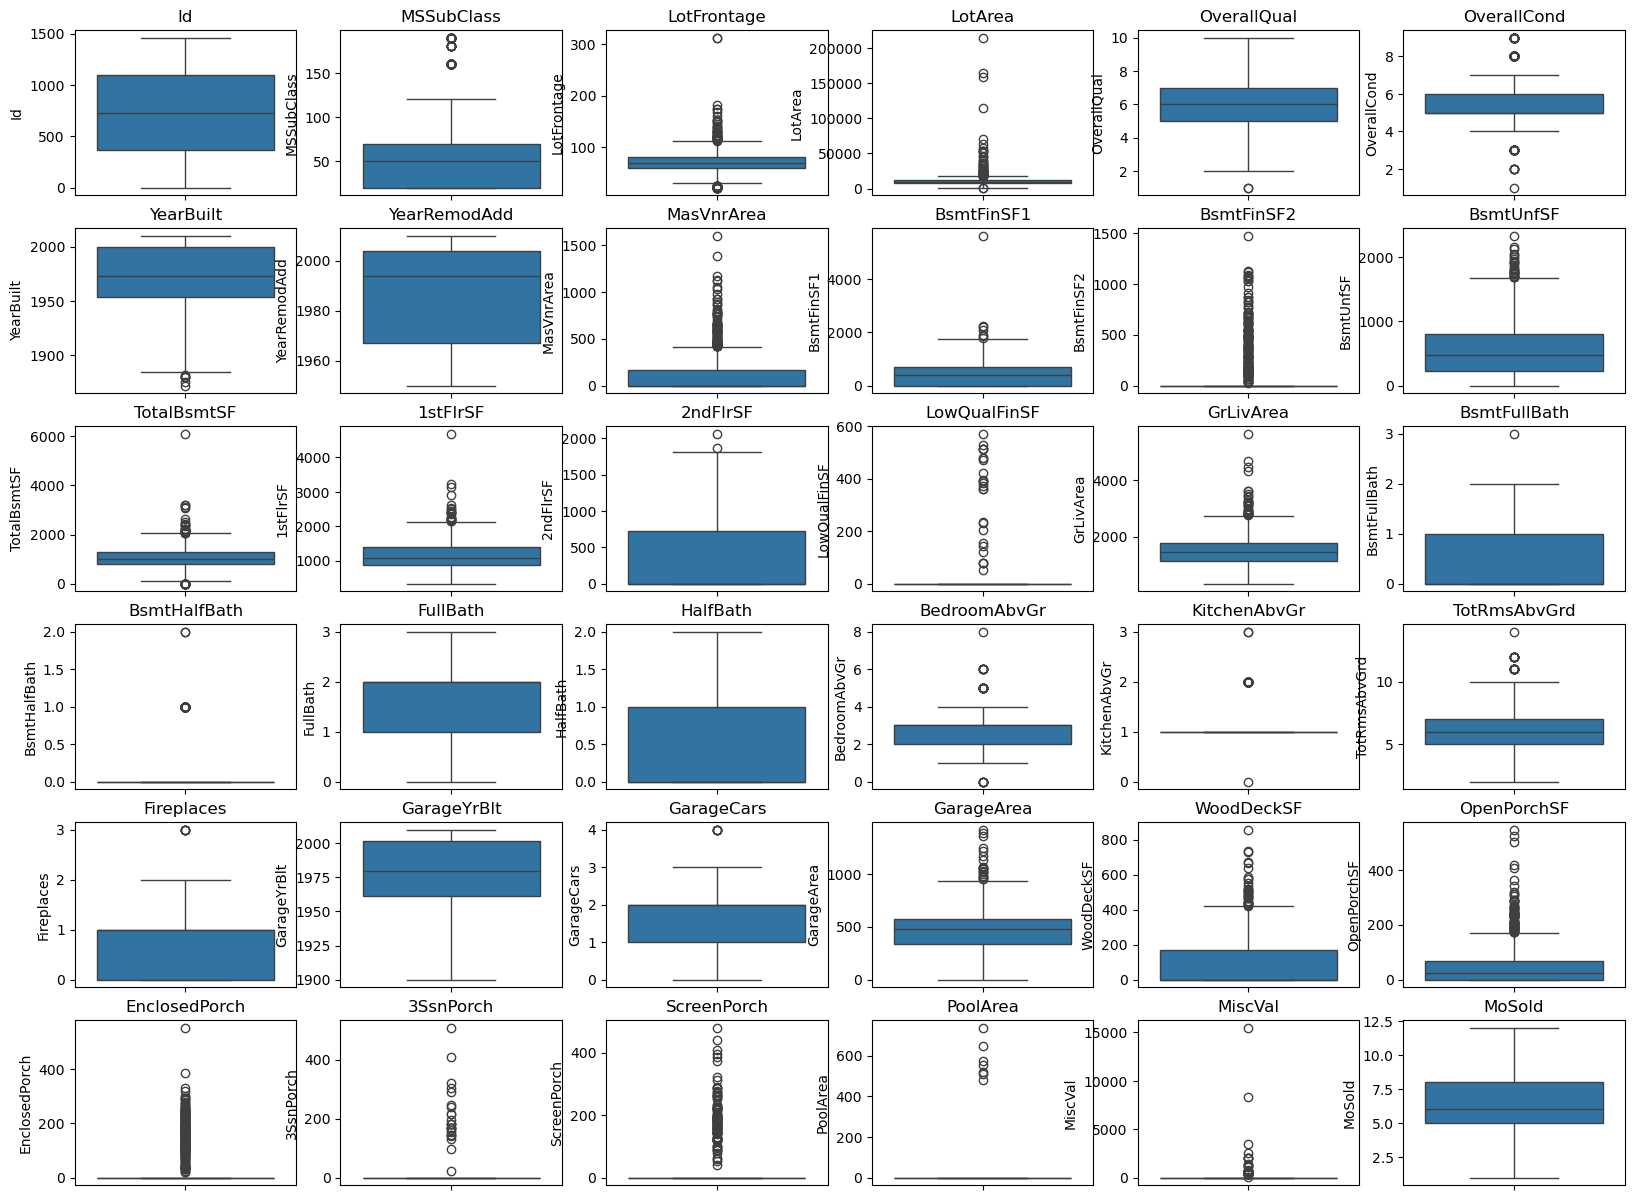

In [29]:
#Detecting Outliers for numericals variables
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols):
    plt.subplot(6, 6, i+1)  # Adjust grid size based on number of columns
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

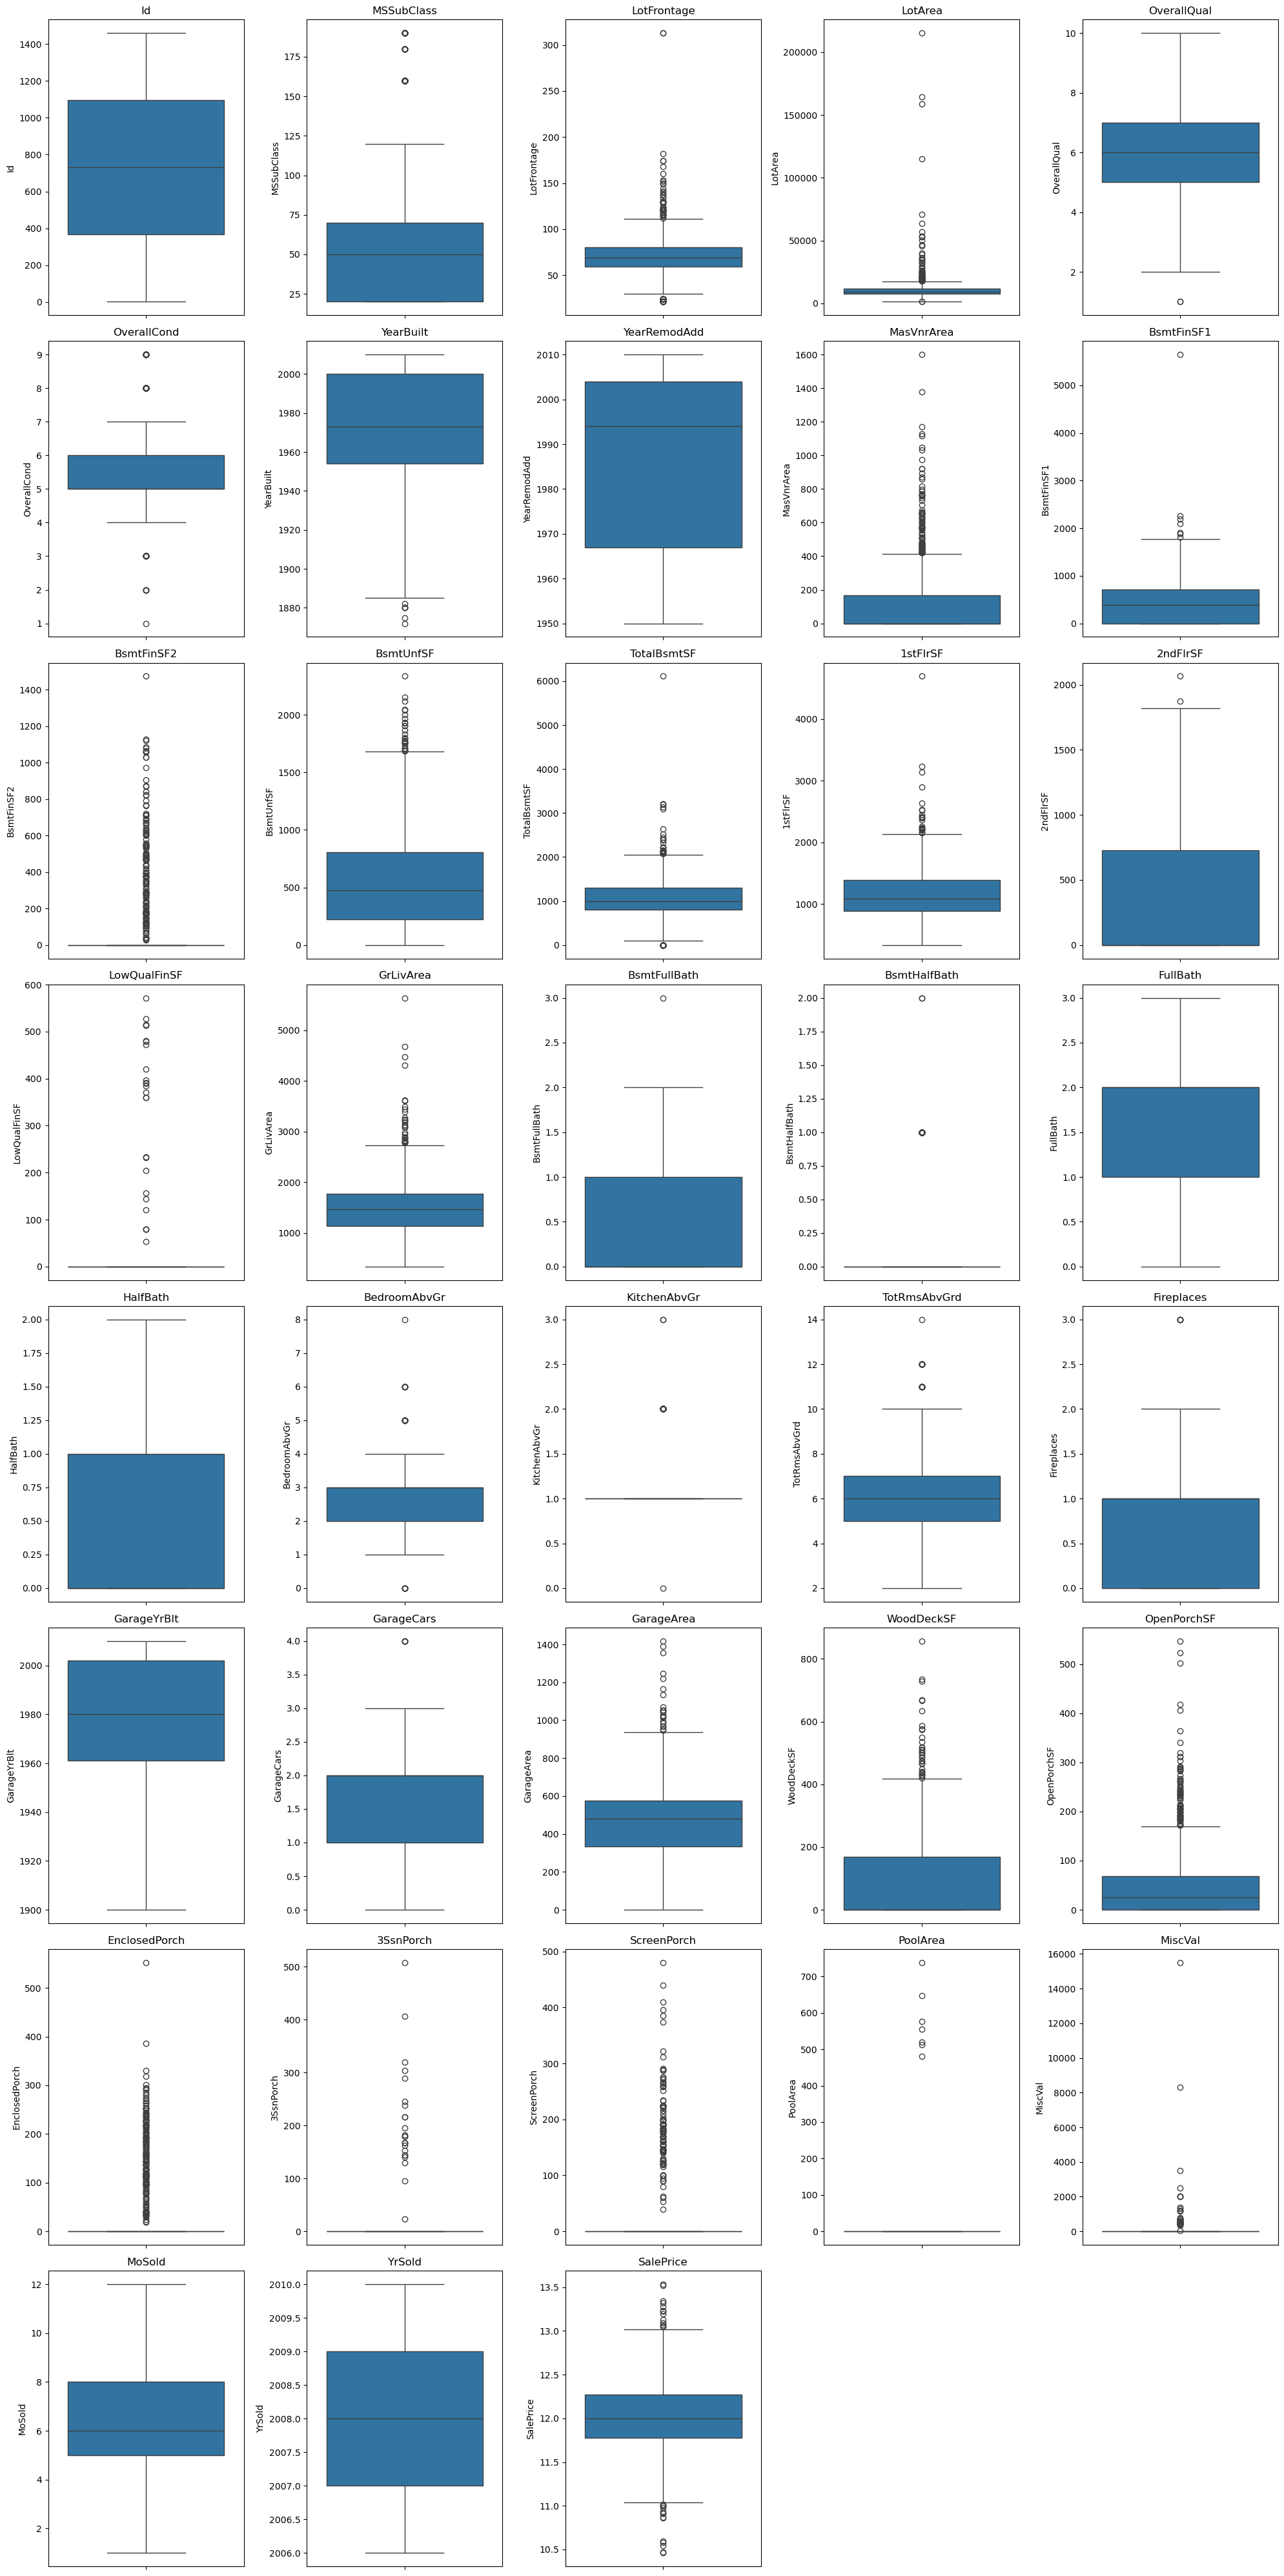

In [30]:
#Alternate Solution as we are getting error
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Ensure only numeric columns
num_cols = train.select_dtypes(include='number').columns

n_cols = 5  # Number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)  # Compute number of rows dynamically

plt.figure(figsize=(20, 5*n_rows))  # Height scales with number of rows
for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(y=train[col])
    plt.title(col)
plt.tight_layout()
plt.show()

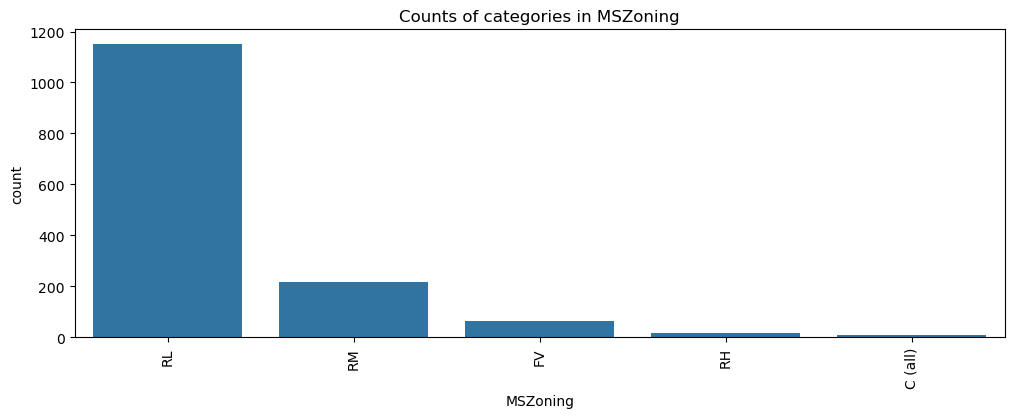

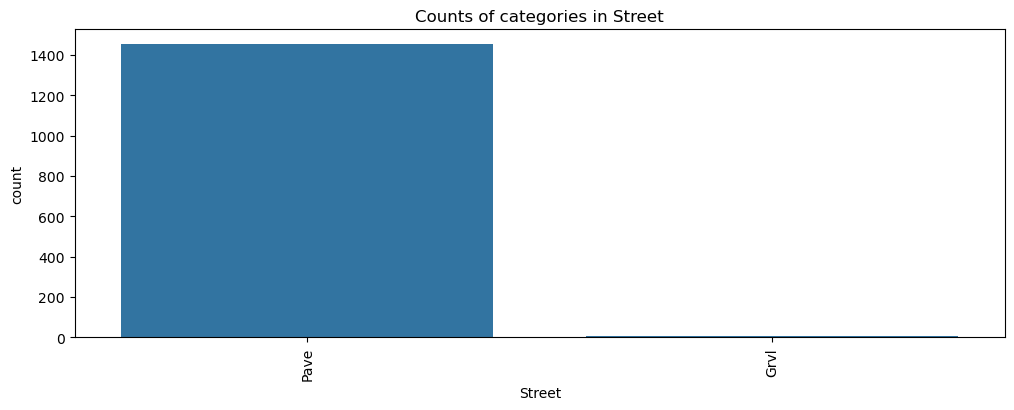

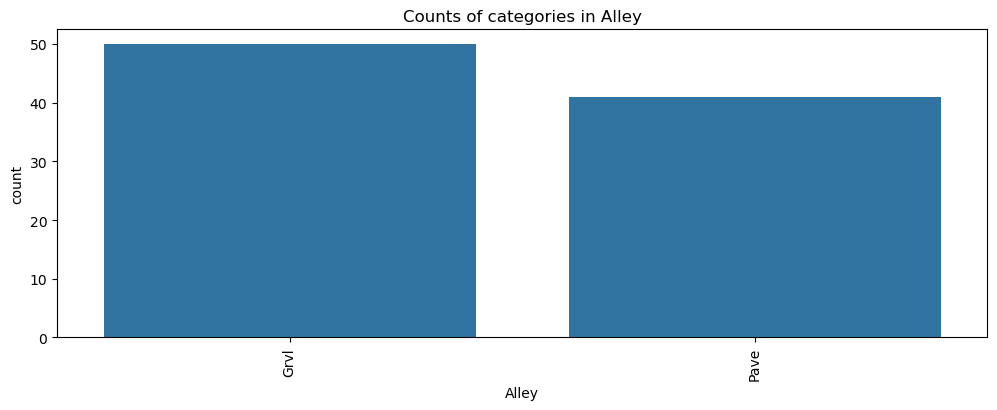

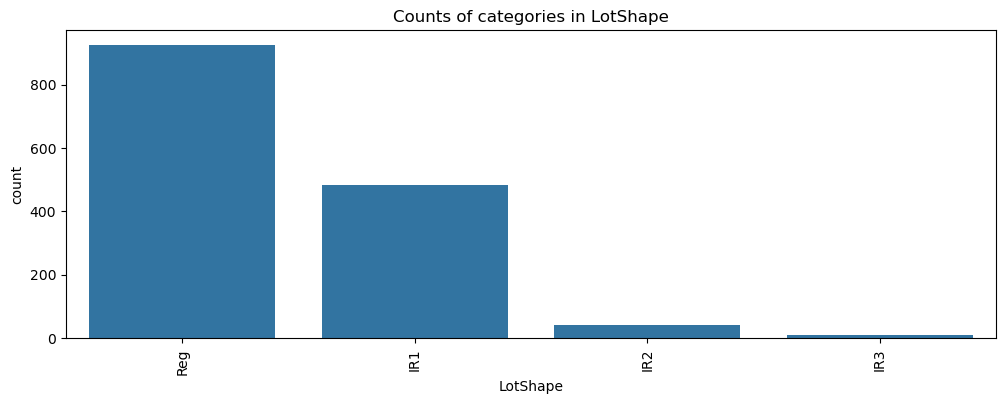

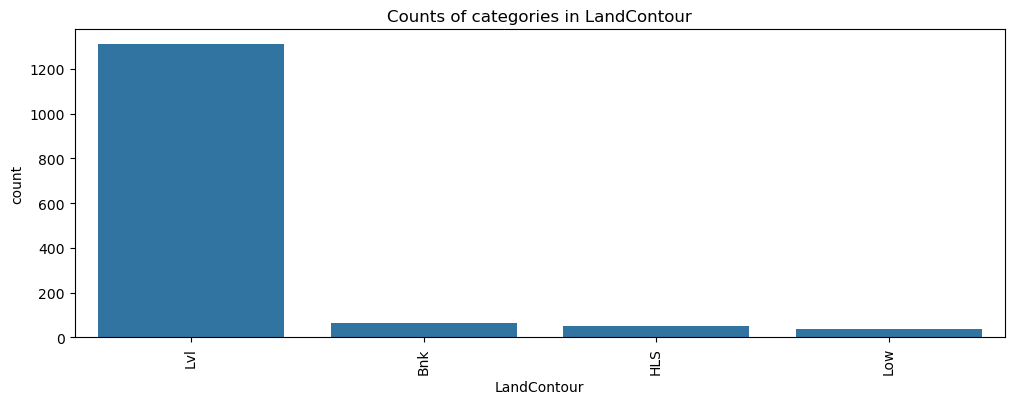

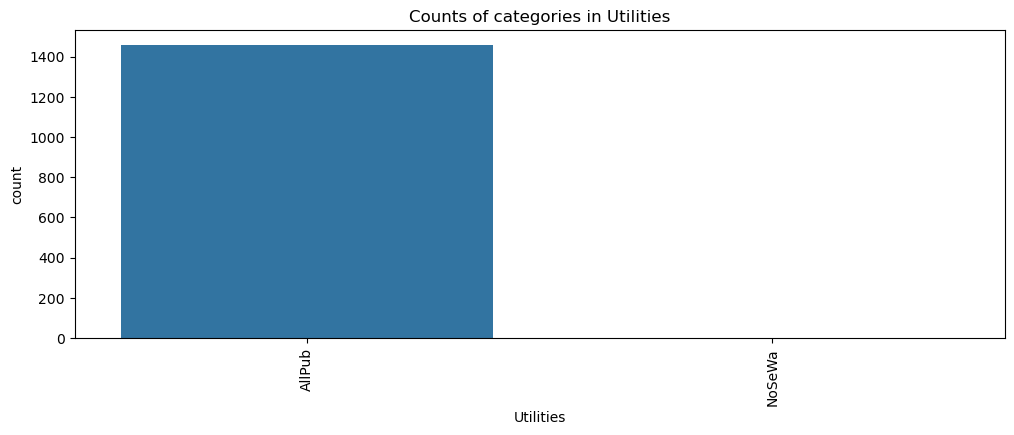

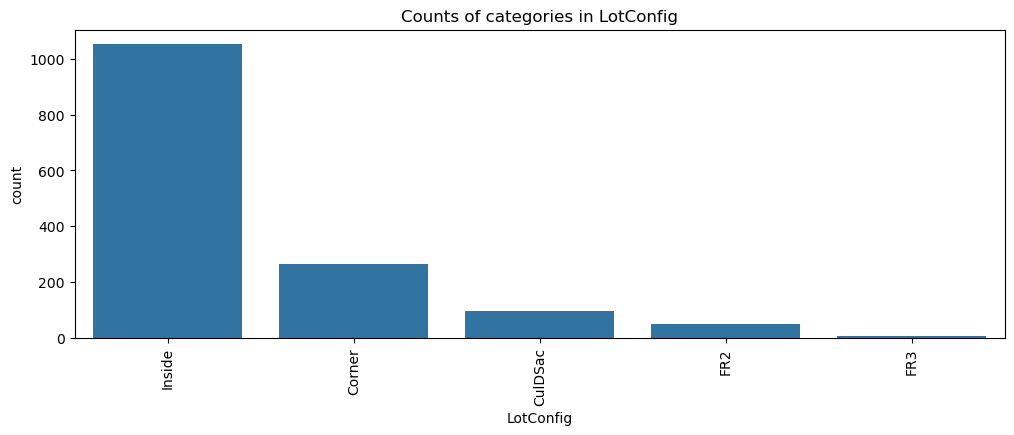

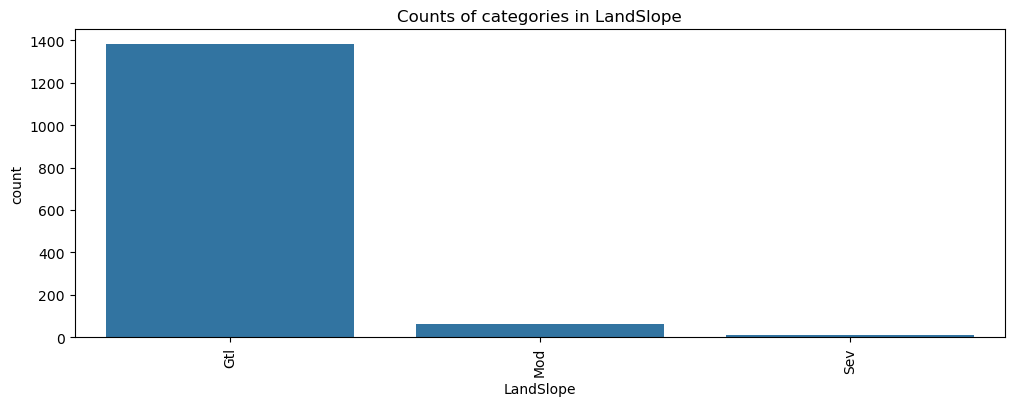

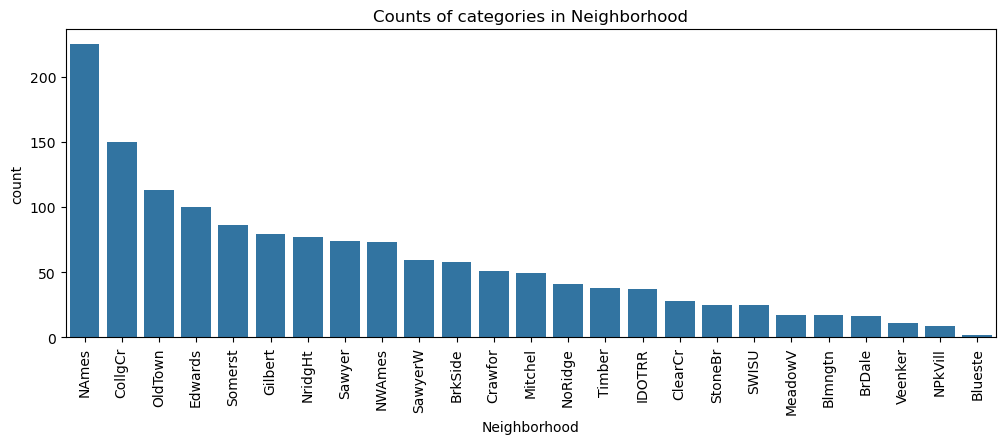

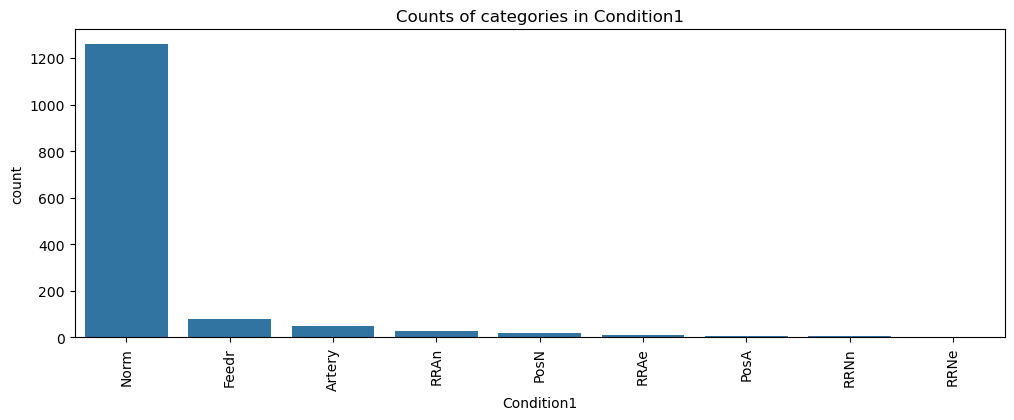

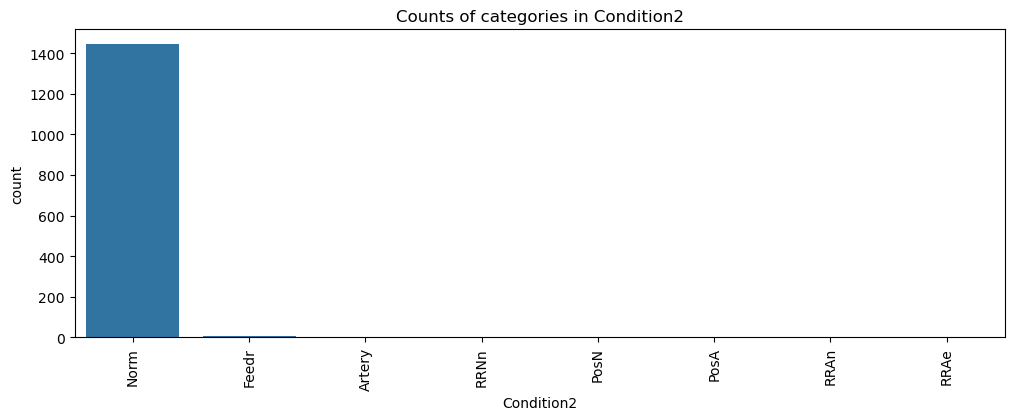

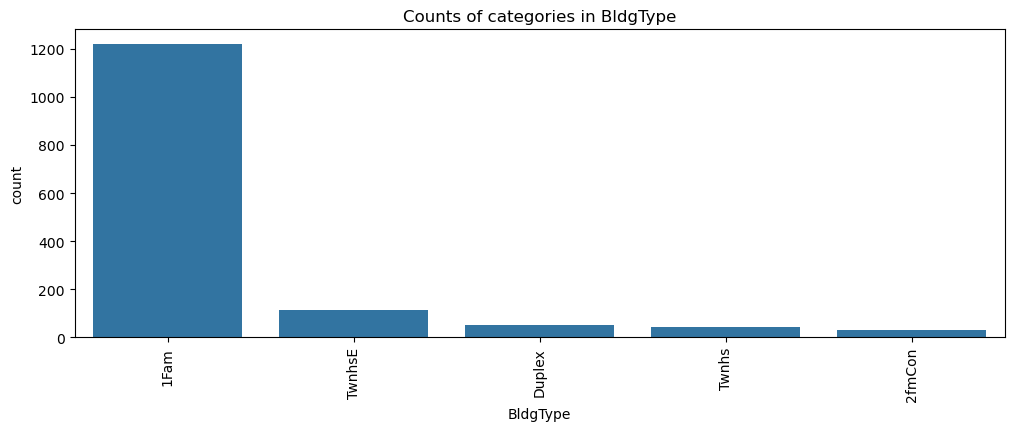

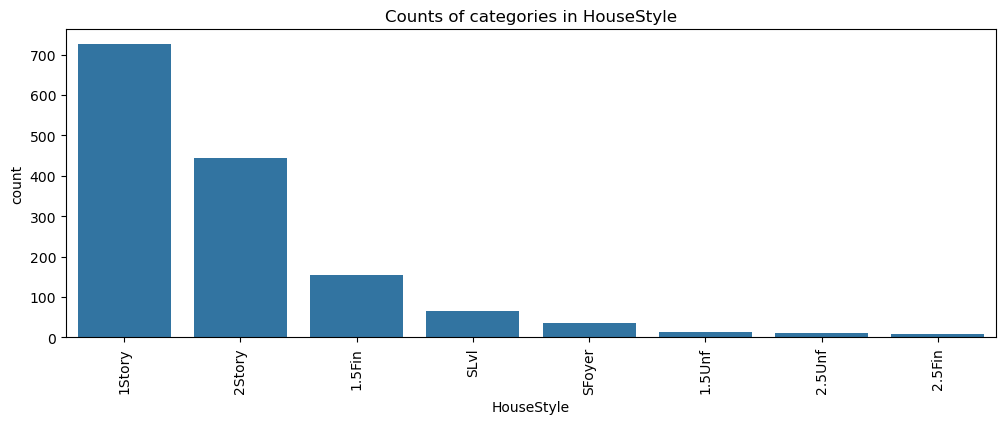

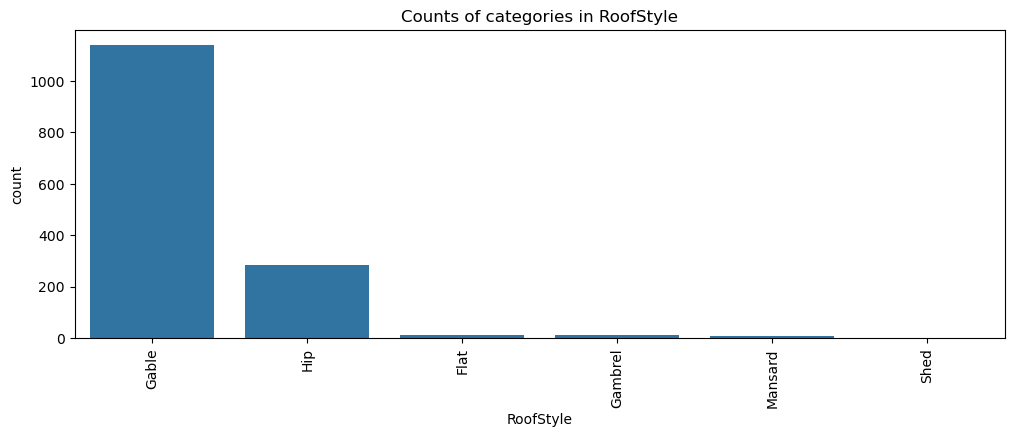

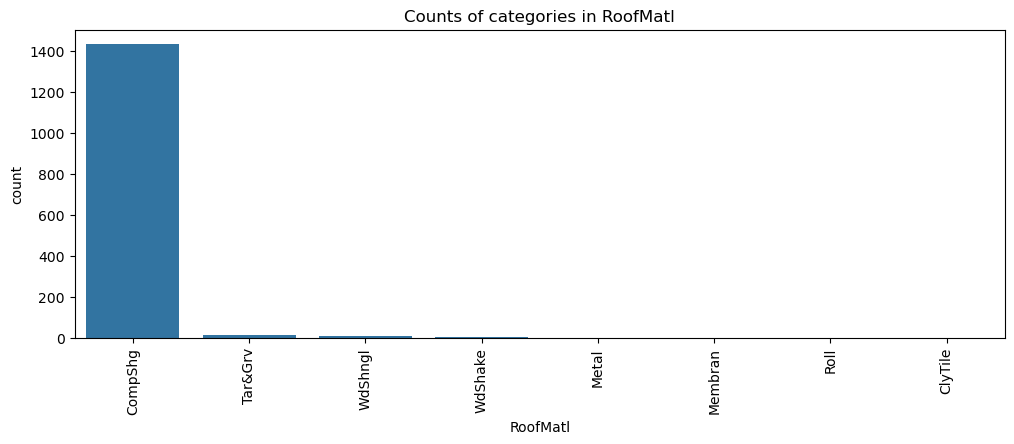

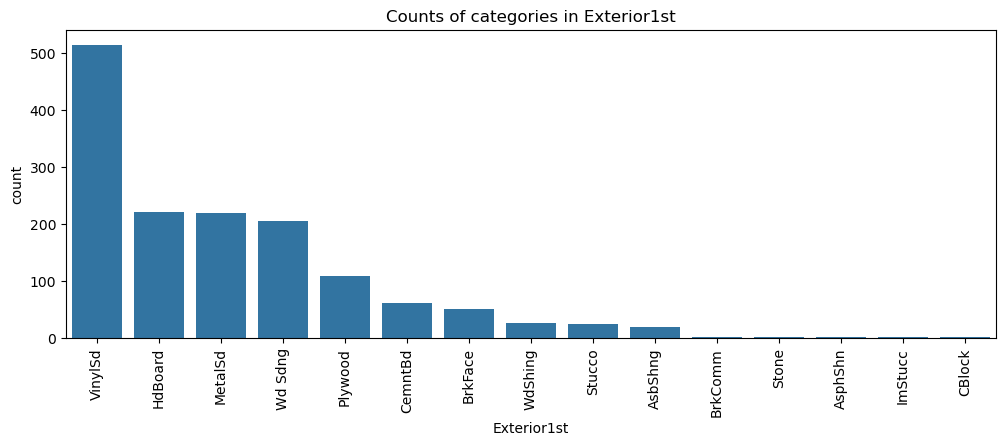

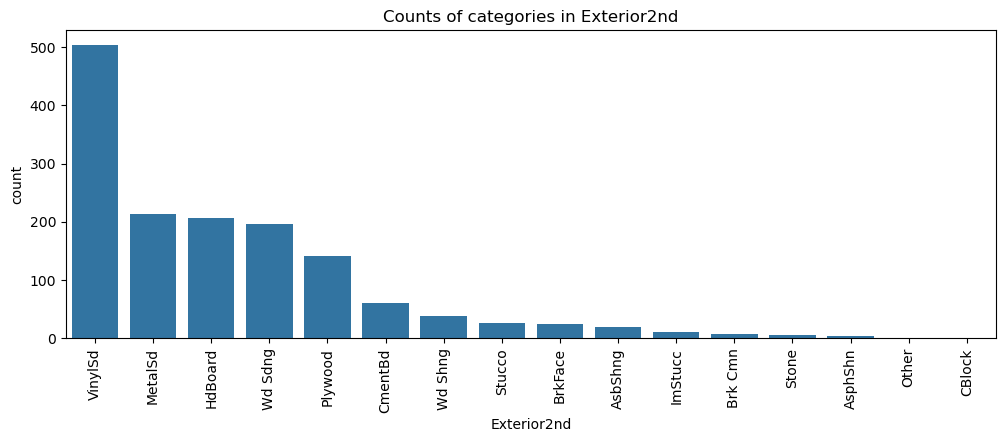

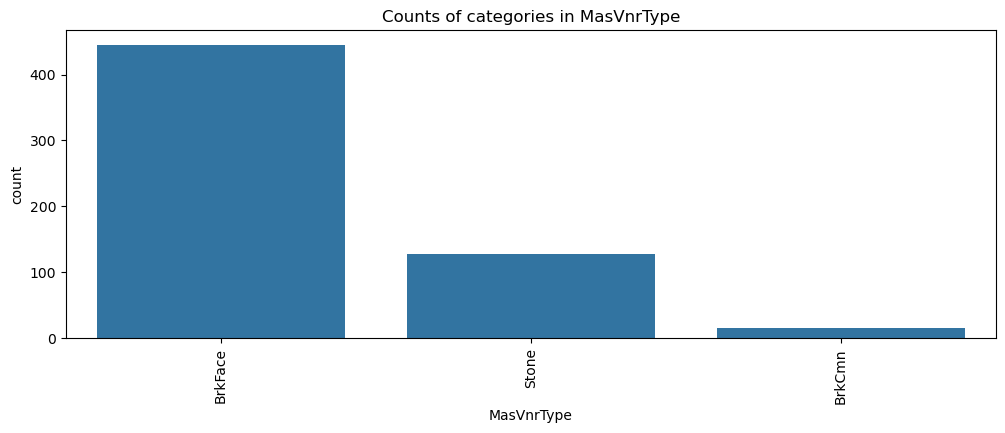

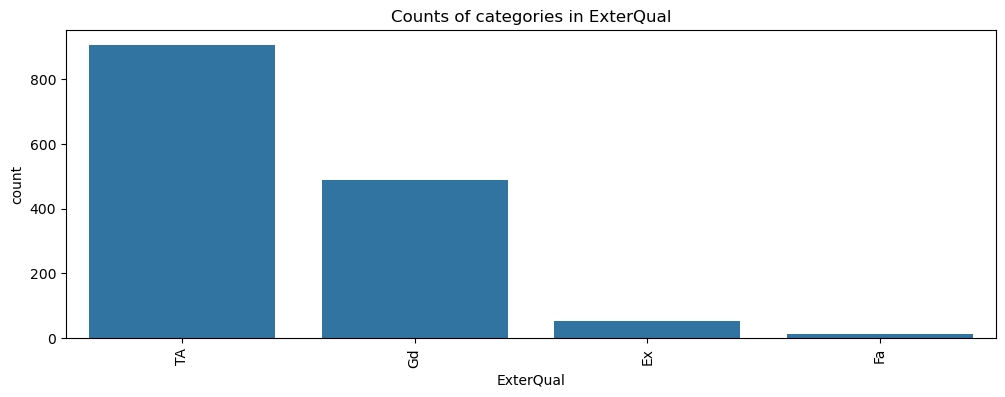

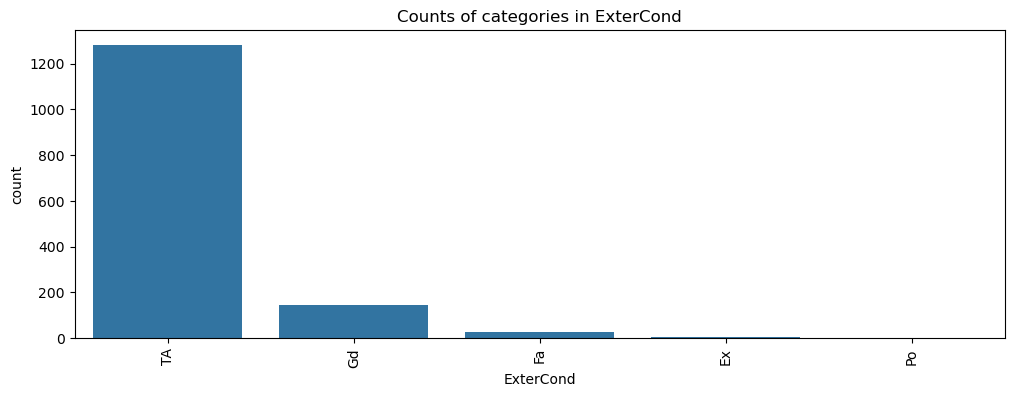

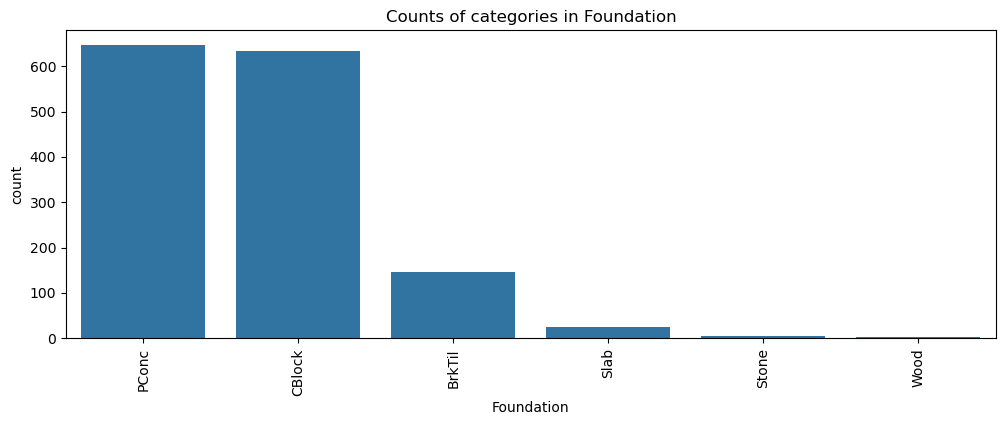

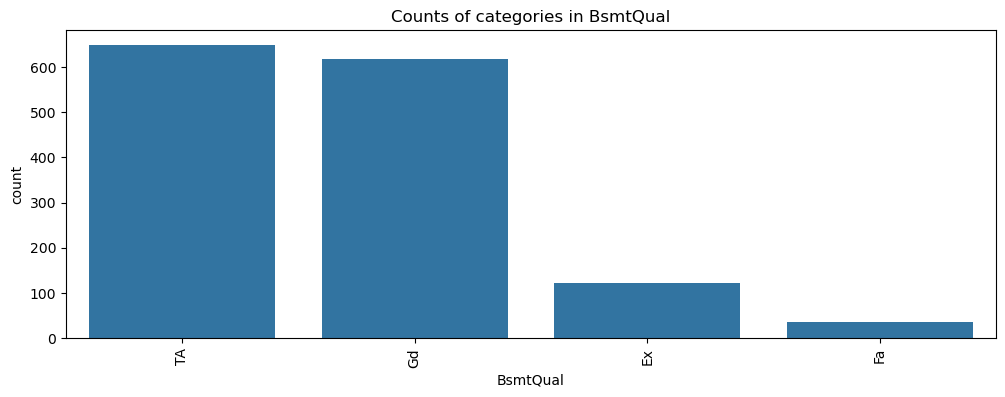

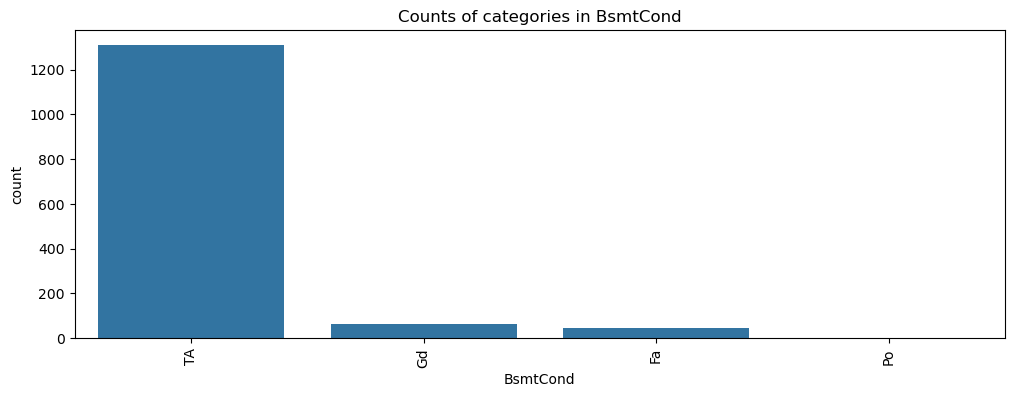

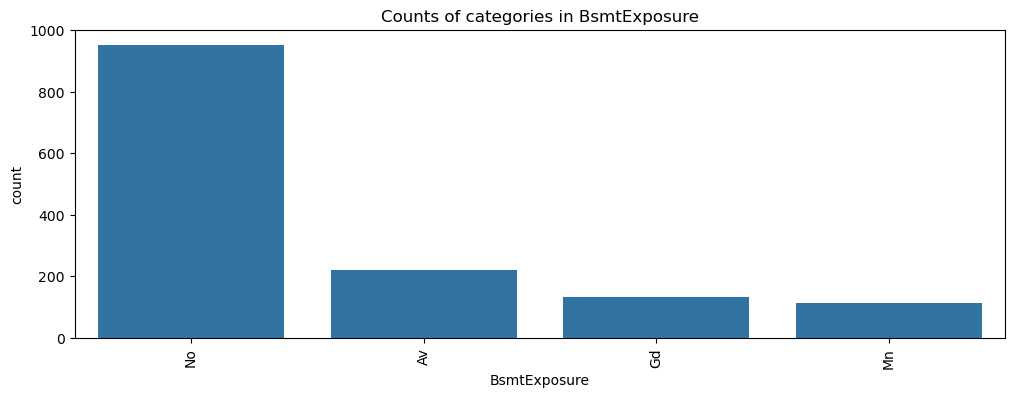

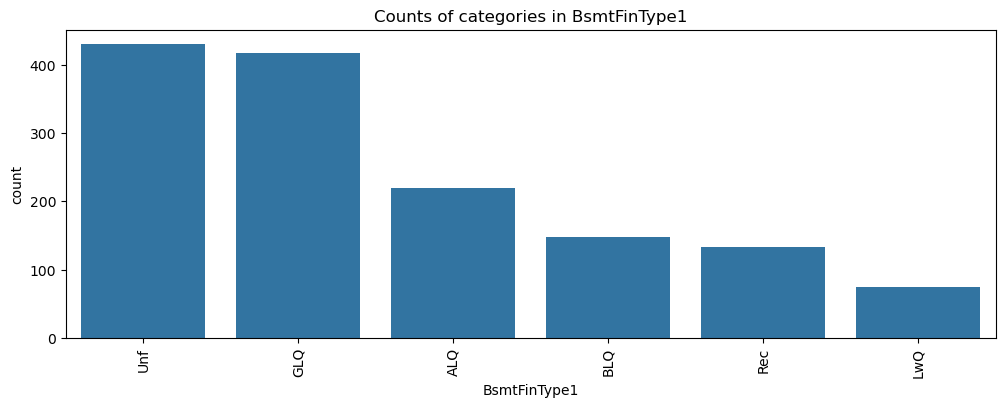

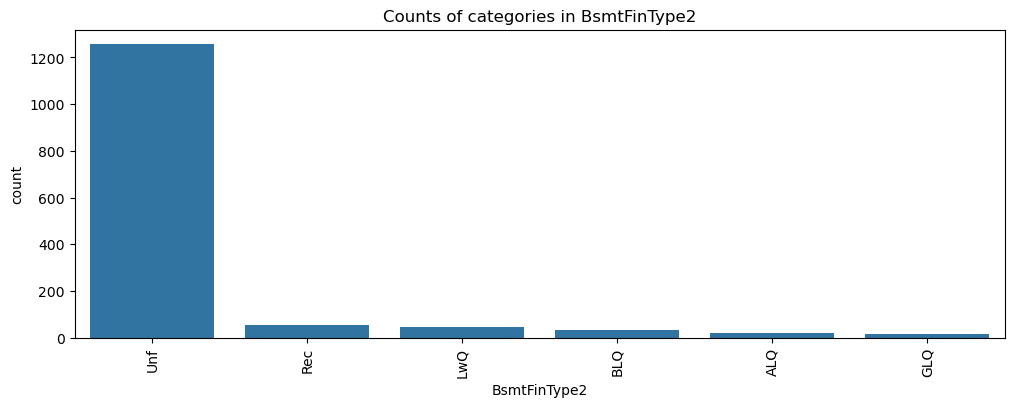

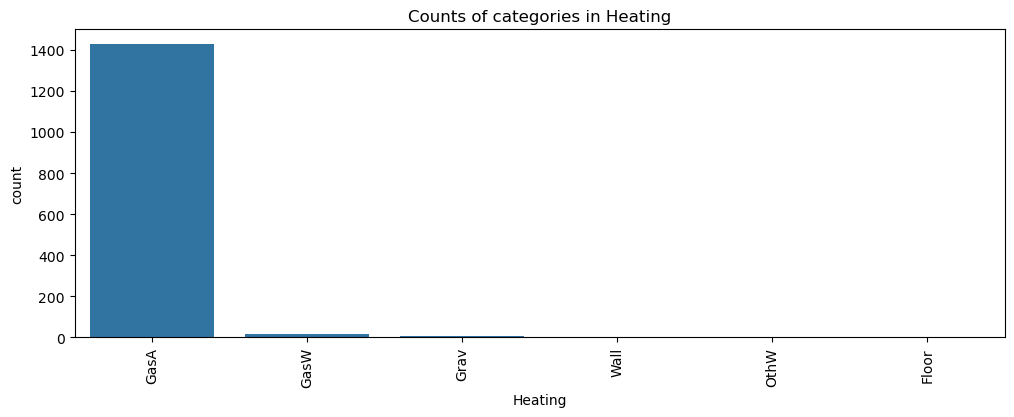

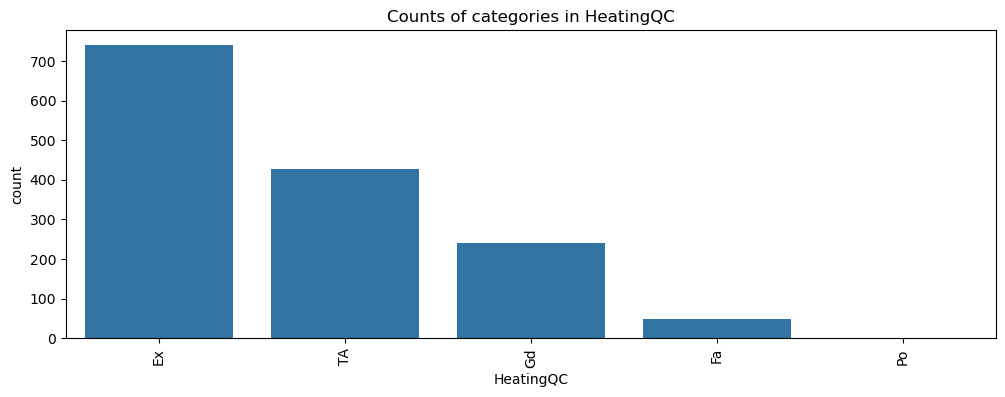

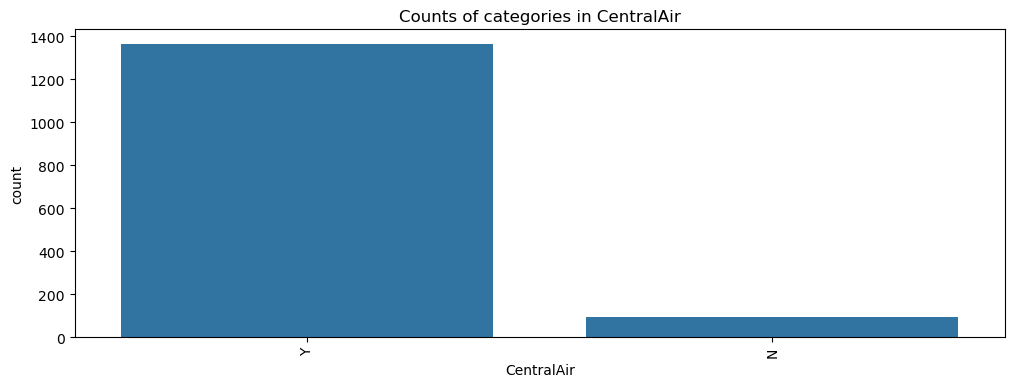

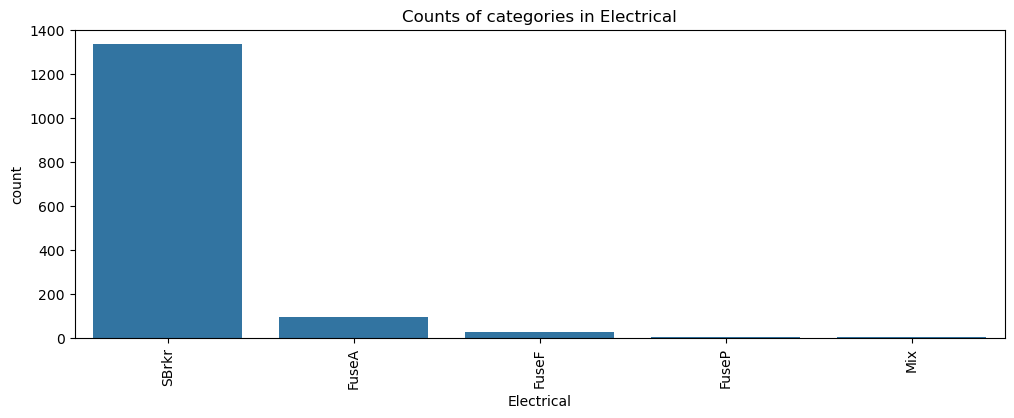

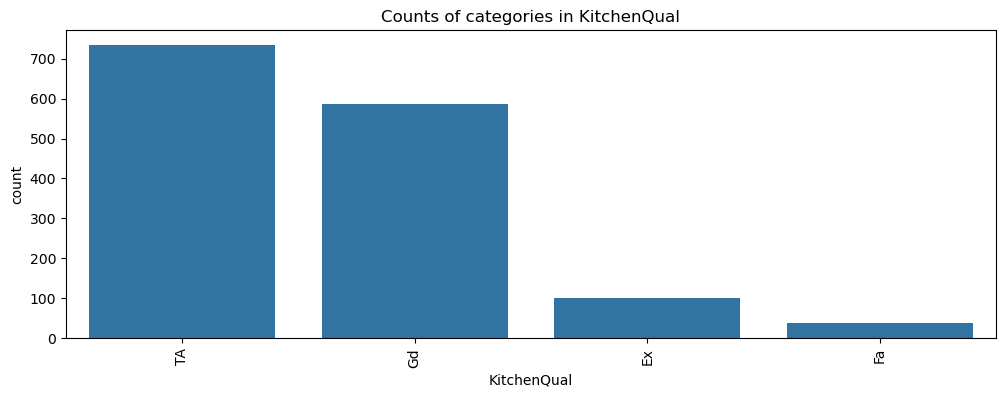

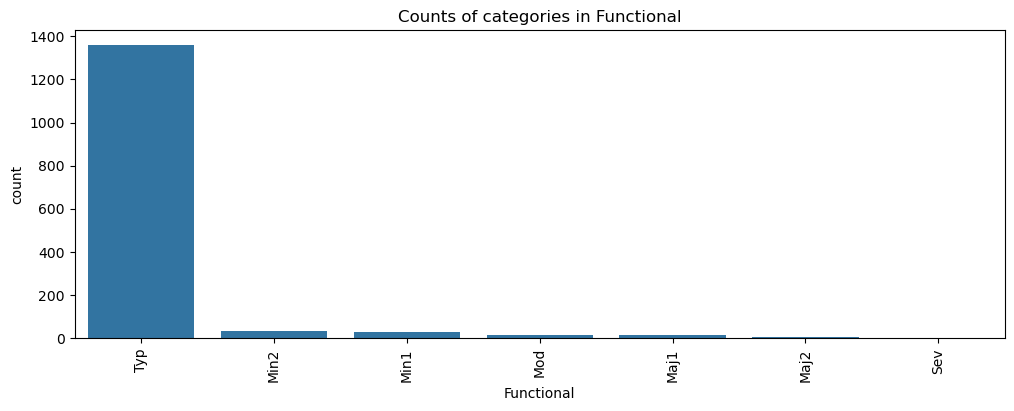

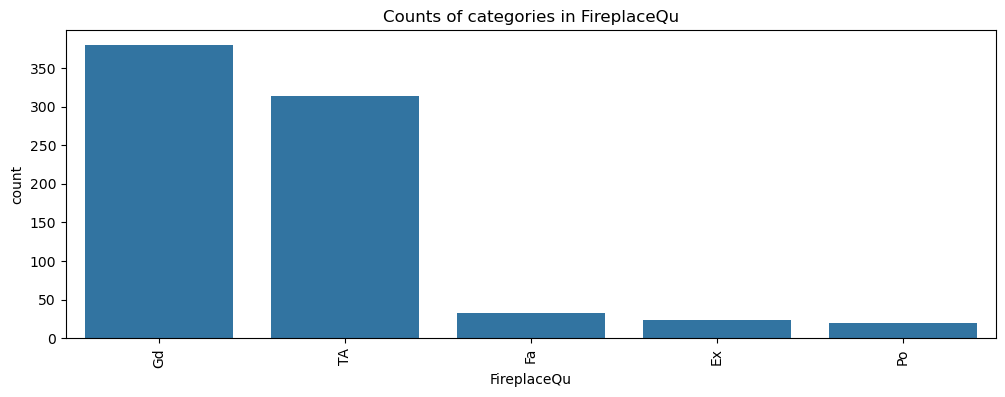

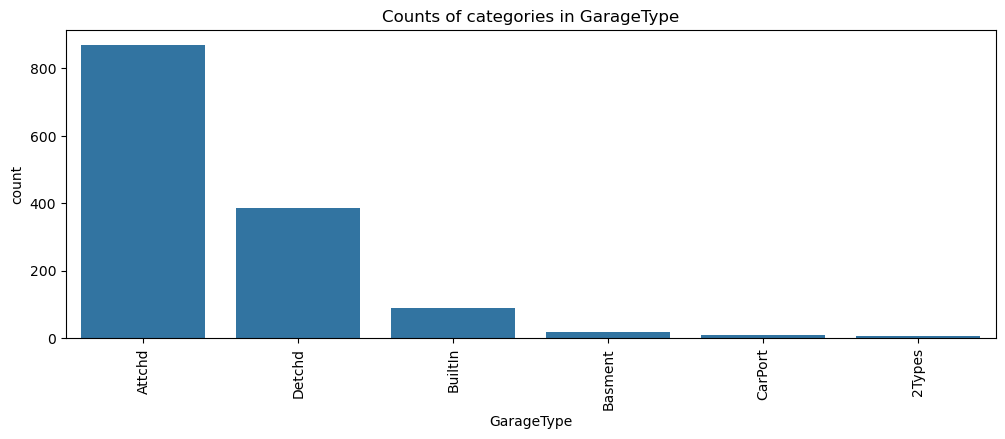

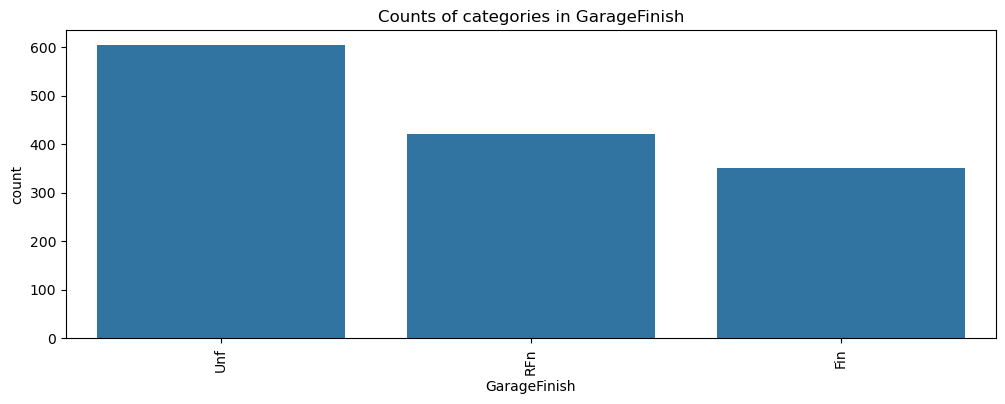

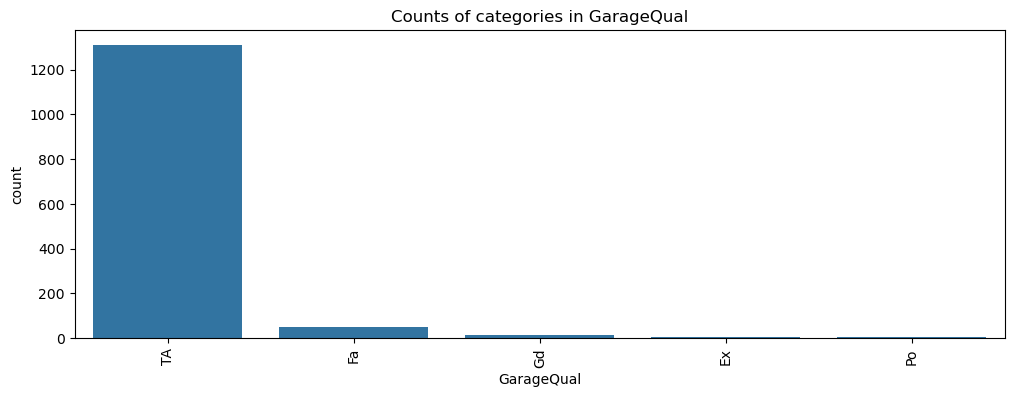

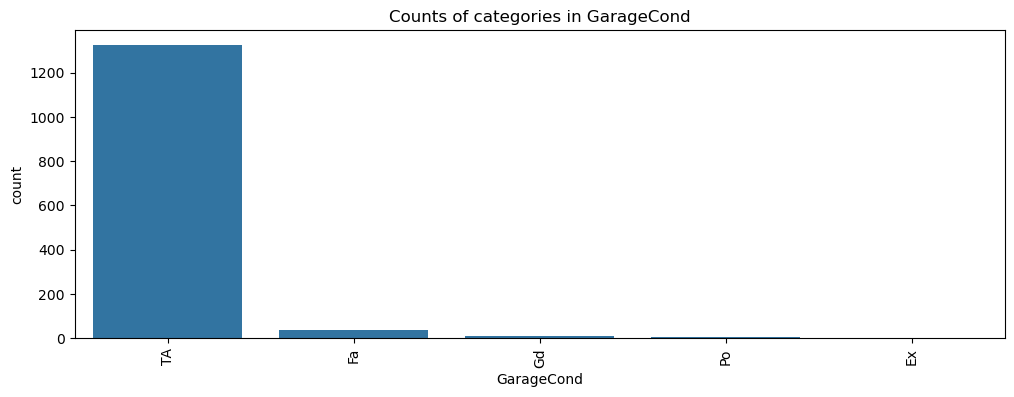

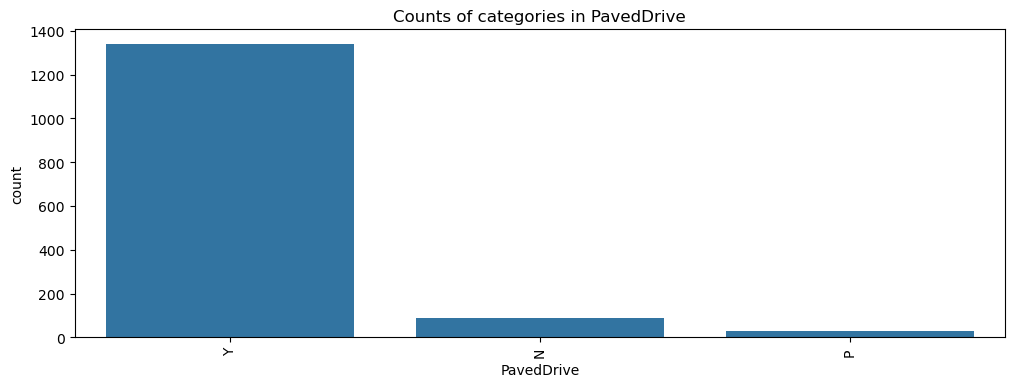

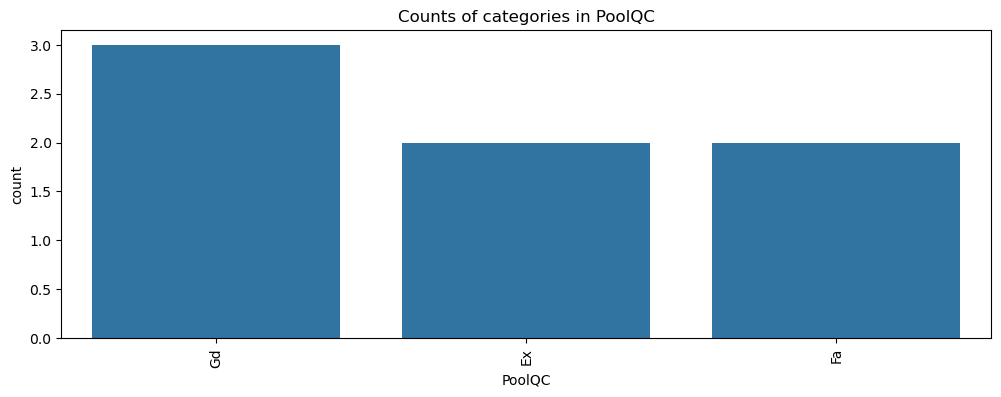

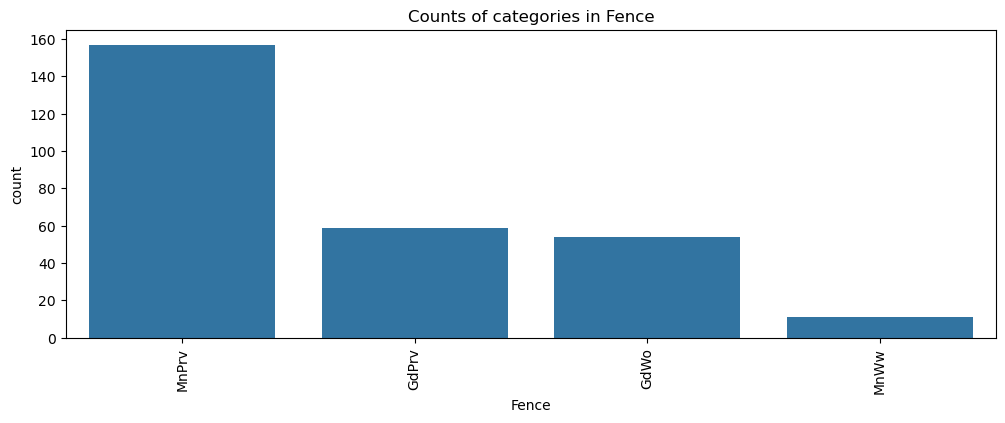

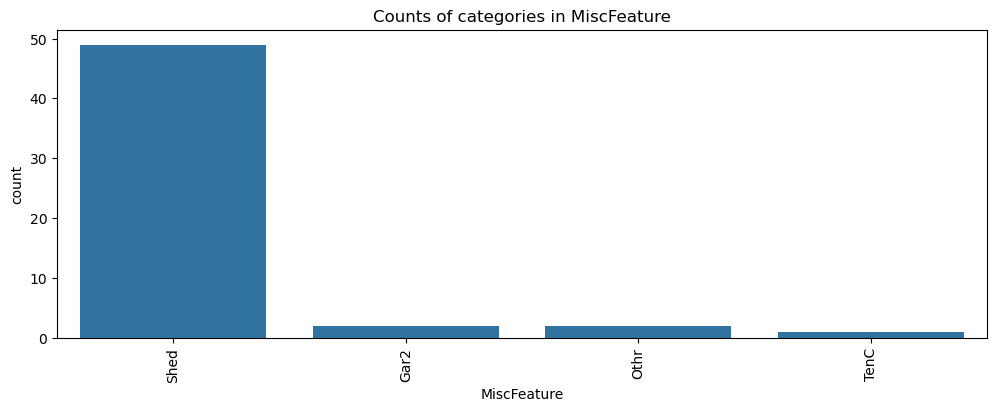

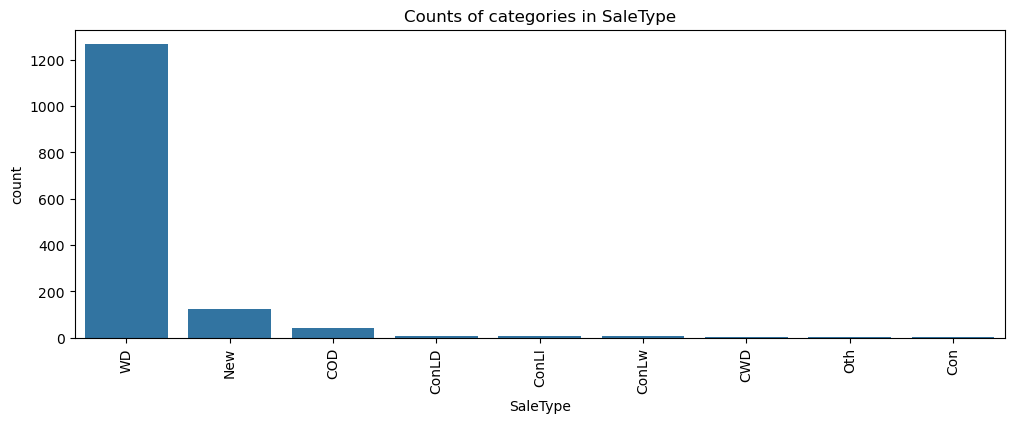

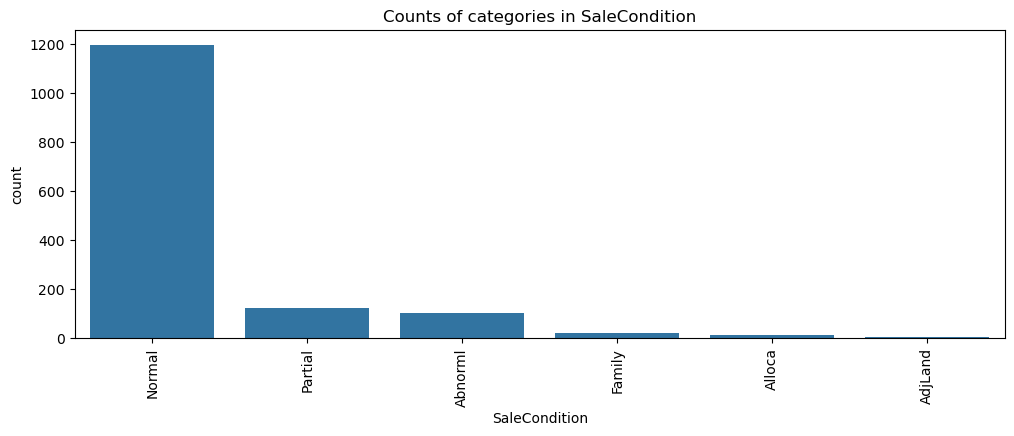

In [31]:
#Detecting Outliers for Categorical variables
import seaborn as sns
import matplotlib.pyplot as plt

for col in cat_cols:
    plt.figure(figsize=(12,4))
    sns.countplot(x=col, data=train, order=train[col].value_counts().index)
    plt.xticks(rotation=90)
    plt.title(f"Counts of categories in {col}")
    plt.show()

In [32]:
# Finding Rare Categories using Threshold in Categorical variables
threshold = 0.05  # 5% of total rows
rare_categories = {}

for col in cat_cols:
    freq = train[col].value_counts(normalize=True)  # percentage
    rare = freq[freq < threshold].index.tolist()
    if rare:
        rare_categories[col] = rare

# Display rare categories
print("Rare categorical values (potential outliers):")
for col, rare in rare_categories.items():
    print(f"{col}: {rare}")

Rare categorical values (potential outliers):
MSZoning: ['FV', 'RH', 'C (all)']
Street: ['Grvl']
LotShape: ['IR2', 'IR3']
LandContour: ['Bnk', 'HLS', 'Low']
Utilities: ['NoSeWa']
LotConfig: ['FR2', 'FR3']
LandSlope: ['Mod', 'Sev']
Neighborhood: ['SawyerW', 'BrkSide', 'Crawfor', 'Mitchel', 'NoRidge', 'Timber', 'IDOTRR', 'ClearCr', 'StoneBr', 'SWISU', 'MeadowV', 'Blmngtn', 'BrDale', 'Veenker', 'NPkVill', 'Blueste']
Condition1: ['Artery', 'RRAn', 'PosN', 'RRAe', 'PosA', 'RRNn', 'RRNe']
Condition2: ['Feedr', 'Artery', 'RRNn', 'PosN', 'PosA', 'RRAn', 'RRAe']
BldgType: ['Duplex', 'Twnhs', '2fmCon']
HouseStyle: ['SLvl', 'SFoyer', '1.5Unf', '2.5Unf', '2.5Fin']
RoofStyle: ['Flat', 'Gambrel', 'Mansard', 'Shed']
RoofMatl: ['Tar&Grv', 'WdShngl', 'WdShake', 'Metal', 'Membran', 'Roll', 'ClyTile']
Exterior1st: ['CemntBd', 'BrkFace', 'WdShing', 'Stucco', 'AsbShng', 'BrkComm', 'Stone', 'AsphShn', 'ImStucc', 'CBlock']
Exterior2nd: ['CmentBd', 'Wd Shng', 'Stucco', 'BrkFace', 'AsbShng', 'ImStucc', 'Brk Cm

In [33]:
#Handling Rare Categories by Replacing then with 'Other'
for col, rares in rare_categories.items():
    train[col] = train[col].apply(lambda x: 'Other' if x in rares else x)

In [34]:
#Applying above login to Test data to ensure consistency between Train and Test
for col, rares in rare_categories.items():
    if col in test.columns:
        allowed = set(train[col].unique())  # categories present in train
        test[col] = test[col].apply(lambda x: x if x in allowed else 'Other')

# Observation
# Helps see which categories are tiny bars → potential outliers

# Feature Engineering

In [35]:
# Split target
y = train['SalePrice']
X = train.drop(['SalePrice'], axis=1)

In [36]:
# Combine
combined = pd.concat([X, test], axis=0)

In [37]:
### Missing Values
## Here we will check the percentage of nan values present in each feature
## 1 -step make the list of features which has missing values
features_with_na=[features for features in combined.columns if combined[features].isnull().sum()>1]
## 2- step print the feature name and the percentage of missing values

for feature in features_with_na:
    print(feature, np.round(combined[feature].isnull().mean(), 4),  ' % missing values')

LotFrontage 0.1665  % missing values
Alley 0.9322  % missing values
MasVnrType 0.605  % missing values
MasVnrArea 0.0079  % missing values
BsmtQual 0.0277  % missing values
BsmtCond 0.0281  % missing values
BsmtExposure 0.0281  % missing values
BsmtFinType1 0.0271  % missing values
BsmtFinType2 0.0274  % missing values
BsmtFullBath 0.0007  % missing values
BsmtHalfBath 0.0007  % missing values
FireplaceQu 0.4865  % missing values
GarageType 0.0538  % missing values
GarageYrBlt 0.0545  % missing values
GarageFinish 0.0545  % missing values
GarageQual 0.0545  % missing values
GarageCond 0.0545  % missing values
PoolQC 0.9966  % missing values
Fence 0.8044  % missing values
MiscFeature 0.964  % missing values


In [38]:
combined['Id'].dtype

dtype('int64')

In [39]:
# Identify numerical and categorical columns
num_cols = combined.select_dtypes(exclude='object').columns
cat_cols = combined.select_dtypes(include='object').columns

In [40]:
#Numerical Columns-Nan values are filled with median
combined[num_cols] = combined[num_cols].fillna(combined[num_cols].median())

In [41]:
#Categorical Columns-Nan values filled with "Missing"
combined[cat_cols] = combined[cat_cols].fillna('Missing')

In [42]:
combined = pd.get_dummies(combined)
combined.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,MiscFeature_Missing,MiscFeature_Other,MiscFeature_Shed,SaleType_New,SaleType_Other,SaleType_WD,SaleCondition_Abnorml,SaleCondition_Normal,SaleCondition_Other,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706.0,...,True,False,False,False,False,True,False,True,False,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978.0,...,True,False,False,False,False,True,False,True,False,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486.0,...,True,False,False,False,False,True,False,True,False,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216.0,...,True,False,False,False,False,True,True,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655.0,...,True,False,False,False,False,True,False,True,False,False


In [43]:
combined.isnull().sum()

Id                       0
MSSubClass               0
LotFrontage              0
LotArea                  0
OverallQual              0
                        ..
SaleType_WD              0
SaleCondition_Abnorml    0
SaleCondition_Normal     0
SaleCondition_Other      0
SaleCondition_Partial    0
Length: 193, dtype: int64

In [44]:
# Split back
X = combined.iloc[:len(X), :]
df_test = combined.iloc[len(X):, :]

In [45]:
# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## Train Multiple Models

In [46]:
models = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    results[name] = rmse
    print(f"{name}: RMSE = {rmse}")

LinearRegression: RMSE = 0.1603586559764789
DecisionTree: RMSE = 0.2106038844859803
RandomForest: RMSE = 0.1482193093812302
KNN: RMSE = 0.22827554465321082


## Select Best Model

In [47]:
best_model_name = min(results, key=results.get)
print('Best Model:', best_model_name)

best_model = models[best_model_name]
best_model.fit(X, y)

Best Model: RandomForest


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predict on Test Data

In [48]:
preds = best_model.predict(df_test)
preds

array([11.72419179, 11.94351166, 12.09251308, ..., 11.92331106,
       11.60421475, 12.36829407], shape=(1459,))

In [49]:
# converts log1p back to SalePrice
preds = np.expm1(preds)
#preds

## Submission

In [50]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': preds
})

submission.to_csv('submission.csv', index=False)
submission.head()

,Id,SalePrice
0,1461,123523.128240
1,1462,153814.892210
2,1463,178529.205429
3,1464,184537.872864
4,1465,196254.008282


In [51]:
submission.to_csv('submission.csv', index=False)

In [52]:
from IPython.display import FileLink
FileLink('submission.csv')

C:\Users\Shilpa B Naikal\submission.csv

In [54]:
import pickle

pickle.dump(best_model, open("model.pkl", "wb"))